In [2]:
# --- Imports ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
path = "dataset/ECG/dataset1/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"
df = pd.read_csv(path)

print("Shape (rows, cols):", df.shape)

Shape (rows, cols): (21799, 28)


In [29]:
df = pd.read_csv("dataset/ECG/dataset1/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv", index_col="ecg_id")


# total number of records
print("Total records:", df.shape[0])

# Checking unqiue patient IDs
print("Unique patient IDs:", df["patient_id"].nunique())

# Checking duplicate patient IDs
print("\nDuplicates:", df["patient_id"].duplicated().sum(), "Duplicates\n")

# Checking number of times duplicated patient IDs appear
print("\nCounts of duplicated patient IDs:\n", df["patient_id"].value_counts().head(99), "\n")


# number of patients
print("Unique patients:", df["patient_id"].nunique())

# distribution of records per patient
record_counts = df.groupby("patient_id").size()
print(record_counts.describe())

# patients with the most ECGs
print(record_counts.sort_values(ascending=False))
# -1 because patient_id is what you collapse on

Total records: 21799
Unique patient IDs: 18869

Duplicates: 2930 Duplicates


Counts of duplicated patient IDs:
 patient_id
9898.0     10
17542.0     9
10107.0     9
8304.0      9
8810.0      8
           ..
16217.0     4
13133.0     4
10327.0     4
20679.0     4
11306.0     4
Name: count, Length: 99, dtype: int64 

Unique patients: 18869
count    18869.000000
mean         1.155281
std          0.523105
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
dtype: float64
patient_id
9898.0     10
17542.0     9
10107.0     9
8304.0      9
15765.0     8
           ..
21786.0     1
21785.0     1
21784.0     1
21783.0     1
21782.0     1
Length: 18869, dtype: int64


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  object 
 9   recording_date                21799 non-null  object 
 10  report                        21799 non-null  object 
 11  scp_codes                     21799 non-null  object 
 12  heart_axis                    13331 non-null  object 
 13  i

,ecg_id,patient_id,age,sex,height,weight,nurse,site,validated_by,strat_fold
count,21799.000000,21799.000000,21799.000000,21799.000000,6974.000000,9421.000000,20326.000000,21782.000000,12421.000000,21799.000000
mean,10926.658379,11250.156521,62.769301,0.479150,166.702323,70.995223,2.291745,1.544945,0.746075,5.503005
std,6302.393366,6235.026404,32.308813,0.499577,10.867321,15.878803,3.254033,4.172883,1.178003,2.874948
min,1.000000,302.000000,2.000000,0.000000,6.000000,5.000000,0.000000,0.000000,0.000000,1.000000
25%,5469.500000,5974.500000,50.000000,0.000000,160.000000,60.000000,0.000000,0.000000,0.000000,3.000000
50%,10926.000000,11419.000000,62.000000,0.000000,166.000000,70.000000,1.000000,1.000000,1.000000,6.000000
75%,16386.500000,16607.500000,72.000000,1.000000,174.000000,80.000000,3.000000,2.000000,1.000000,8.000000
max,21837.000000,21797.000000,300.000000,1.000000,209.000000,250.000000,11.000000,50.000000,11.000000,10.000000


In [10]:
 # Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)
print("Missing values in percentage:\n", (missing_values / len(df)) * 100)

Missing values per column:
 ecg_id                              0
patient_id                          0
age                                 0
sex                                 0
height                          14825
weight                          12378
nurse                            1473
site                               17
device                              0
recording_date                      0
report                              0
scp_codes                           0
heart_axis                       8468
infarction_stadium1             16187
infarction_stadium2             21696
validated_by                     9378
second_opinion                      0
initial_autogenerated_report        0
validated_by_human                  0
baseline_drift                  20201
static_noise                    18539
burst_noise                     21186
electrodes_problems             21769
extra_beats                     19850
pacemaker                       21508
strat_fold            

In [11]:
# Checking for unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_values = df[col].nunique()
    print(f"Column '{col}' has {unique_values} unique values.")

Column 'device' has 11 unique values.
Column 'recording_date' has 21795 unique values.
Column 'report' has 9887 unique values.
Column 'scp_codes' has 5463 unique values.
Column 'heart_axis' has 8 unique values.
Column 'infarction_stadium1' has 6 unique values.
Column 'infarction_stadium2' has 3 unique values.
Column 'baseline_drift' has 317 unique values.
Column 'static_noise' has 124 unique values.
Column 'burst_noise' has 103 unique values.
Column 'electrodes_problems' has 14 unique values.
Column 'extra_beats' has 128 unique values.
Column 'pacemaker' has 4 unique values.
Column 'filename_lr' has 21799 unique values.
Column 'filename_hr' has 21799 unique values.


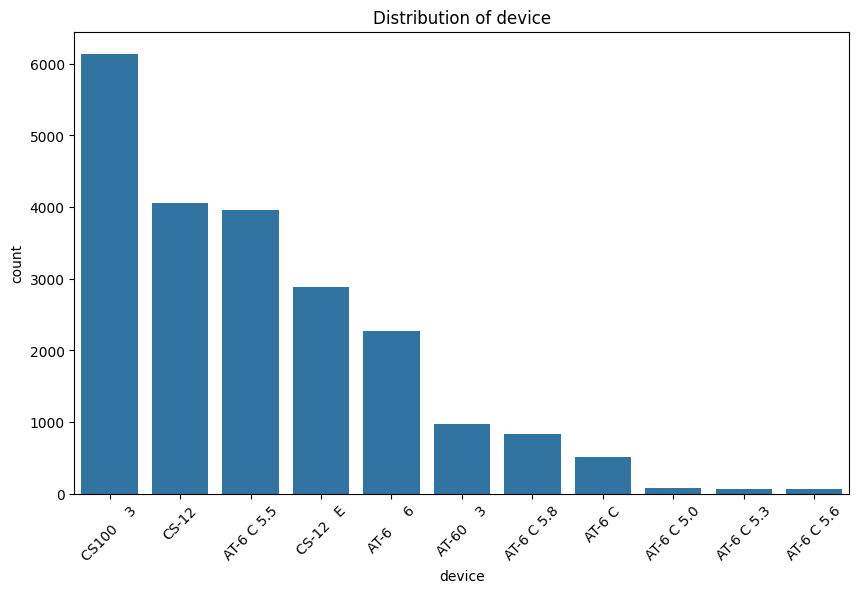

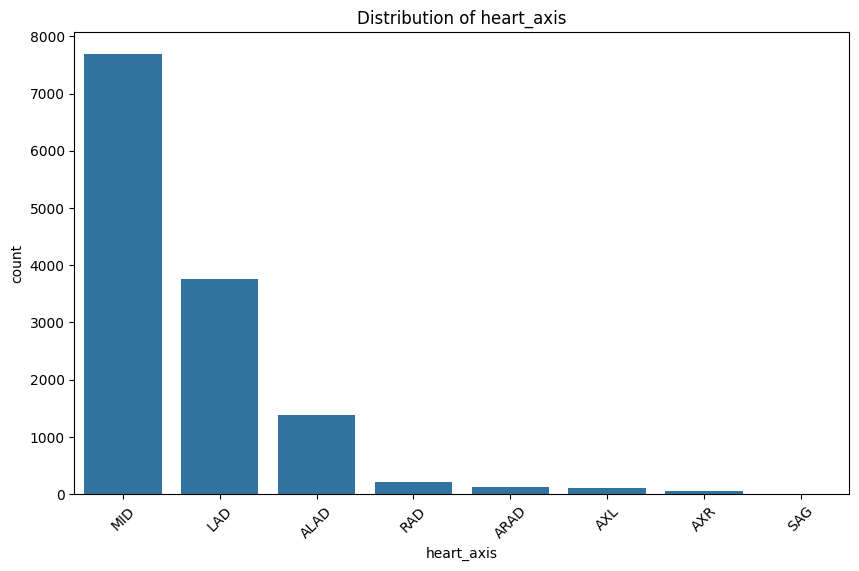

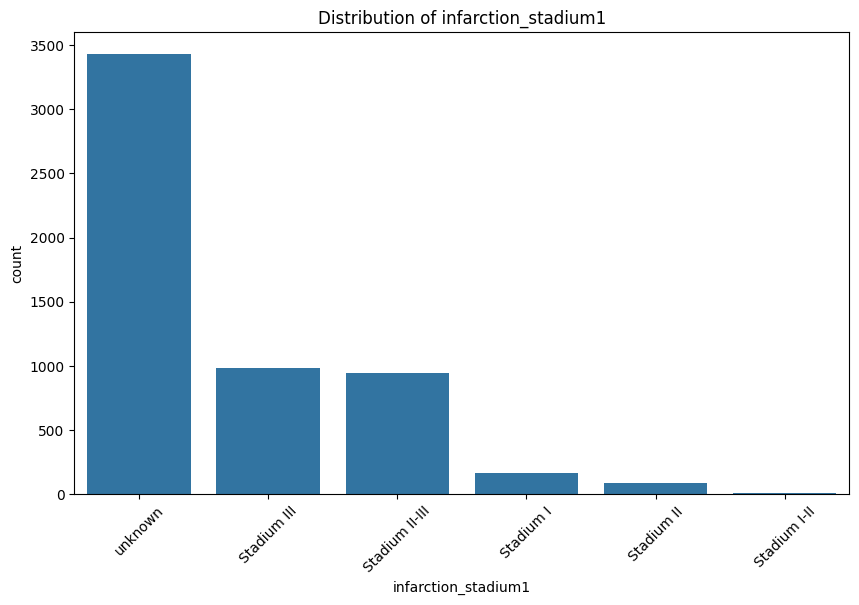

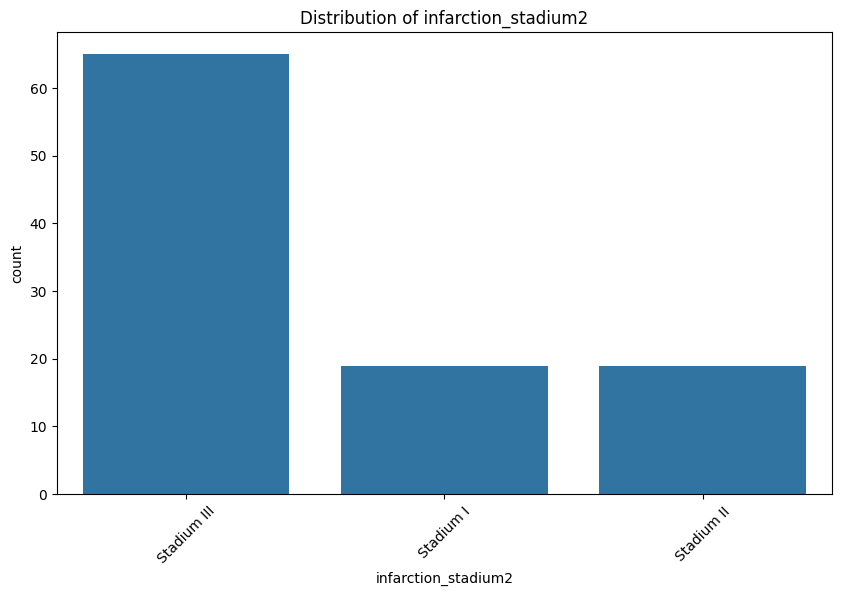

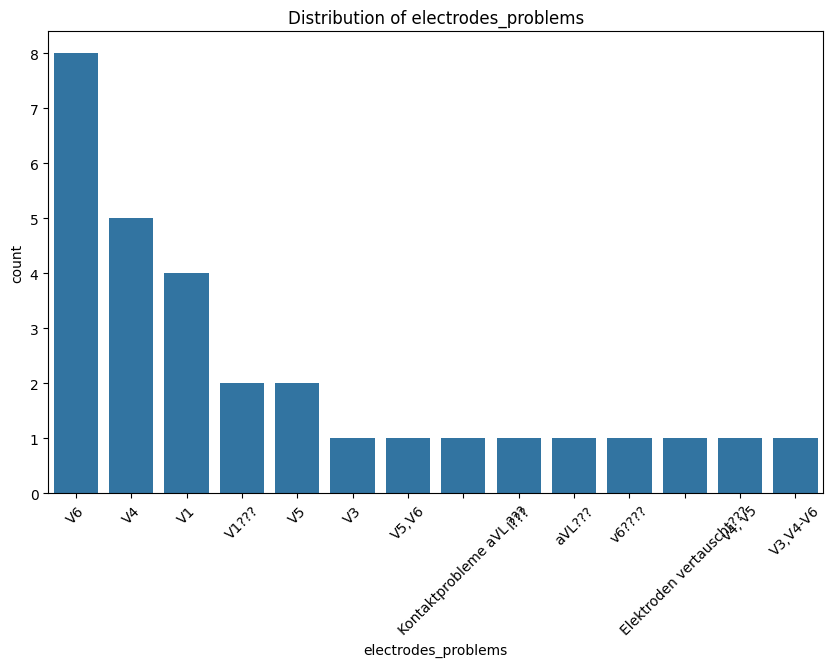

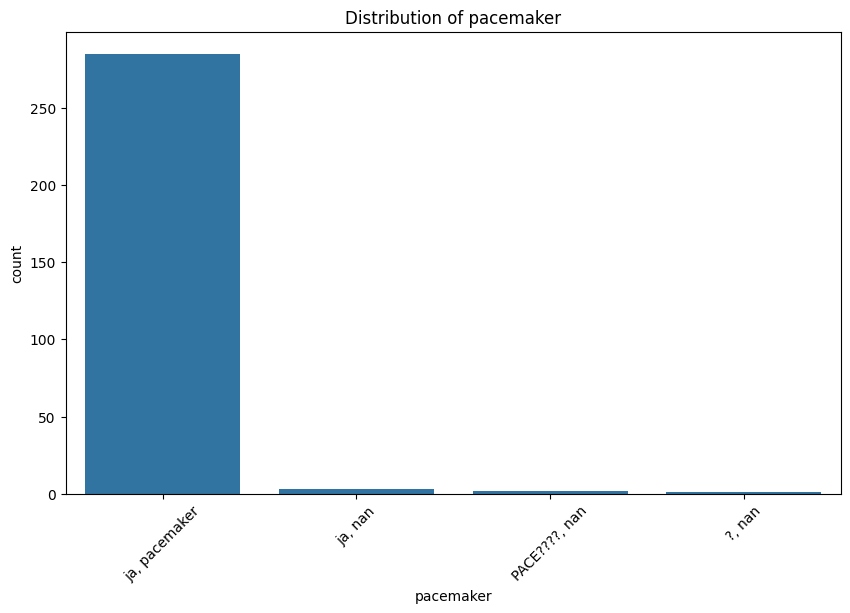

In [13]:
# Visualize all categorical rows of columns with less than 15 unique values

for col in categorical_cols:
    if df[col].nunique() < 15:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.show()

In [24]:
import pandas as pd
import numpy as np
import wfdb
import ast

def load_raw_data(df, sampling_rate):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(f) for f in df.filename_lr]
        print(sampling_rate)
    else:
        data = [wfdb.rdsamp(f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data


sampling_rate=100

path = "dataset/ECG/dataset1/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

# load and convert annotation data
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
#Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

print("\n", Y.scp_codes.head())
print("\n", Y.head())


"""
# Load raw signal data
X = load_raw_data(Y, sampling_rate)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

print(X_train.shape, len(y_train))
print(X_test.shape, len(y_test))
print(y_train.value_counts())
print(y_test.value_counts())"""


 ecg_id
1    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
2                {'NORM': 80.0, 'SBRAD': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
5                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: object

         patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspann

"\n# Load raw signal data\nX = load_raw_data(Y, sampling_rate)\n\n# Load scp_statements.csv for diagnostic aggregation\nagg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)\nagg_df = agg_df[agg_df.diagnostic == 1]\n\ndef aggregate_diagnostic(y_dic):\n    tmp = []\n    for key in y_dic.keys():\n        if key in agg_df.index:\n            tmp.append(agg_df.loc[key].diagnostic_class)\n    return list(set(tmp))\n\n# Apply diagnostic superclass\nY['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)\n\n# Split data into train and test\ntest_fold = 10\n# Train\nX_train = X[np.where(Y.strat_fold != test_fold)]\ny_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass\n# Test\nX_test = X[np.where(Y.strat_fold == test_fold)]\ny_test = Y[Y.strat_fold == test_fold].diagnostic_superclass\n\nprint(X_train.shape, len(y_train))\nprint(X_test.shape, len(y_test))\nprint(y_train.value_counts())\nprint(y_test.value_counts())"